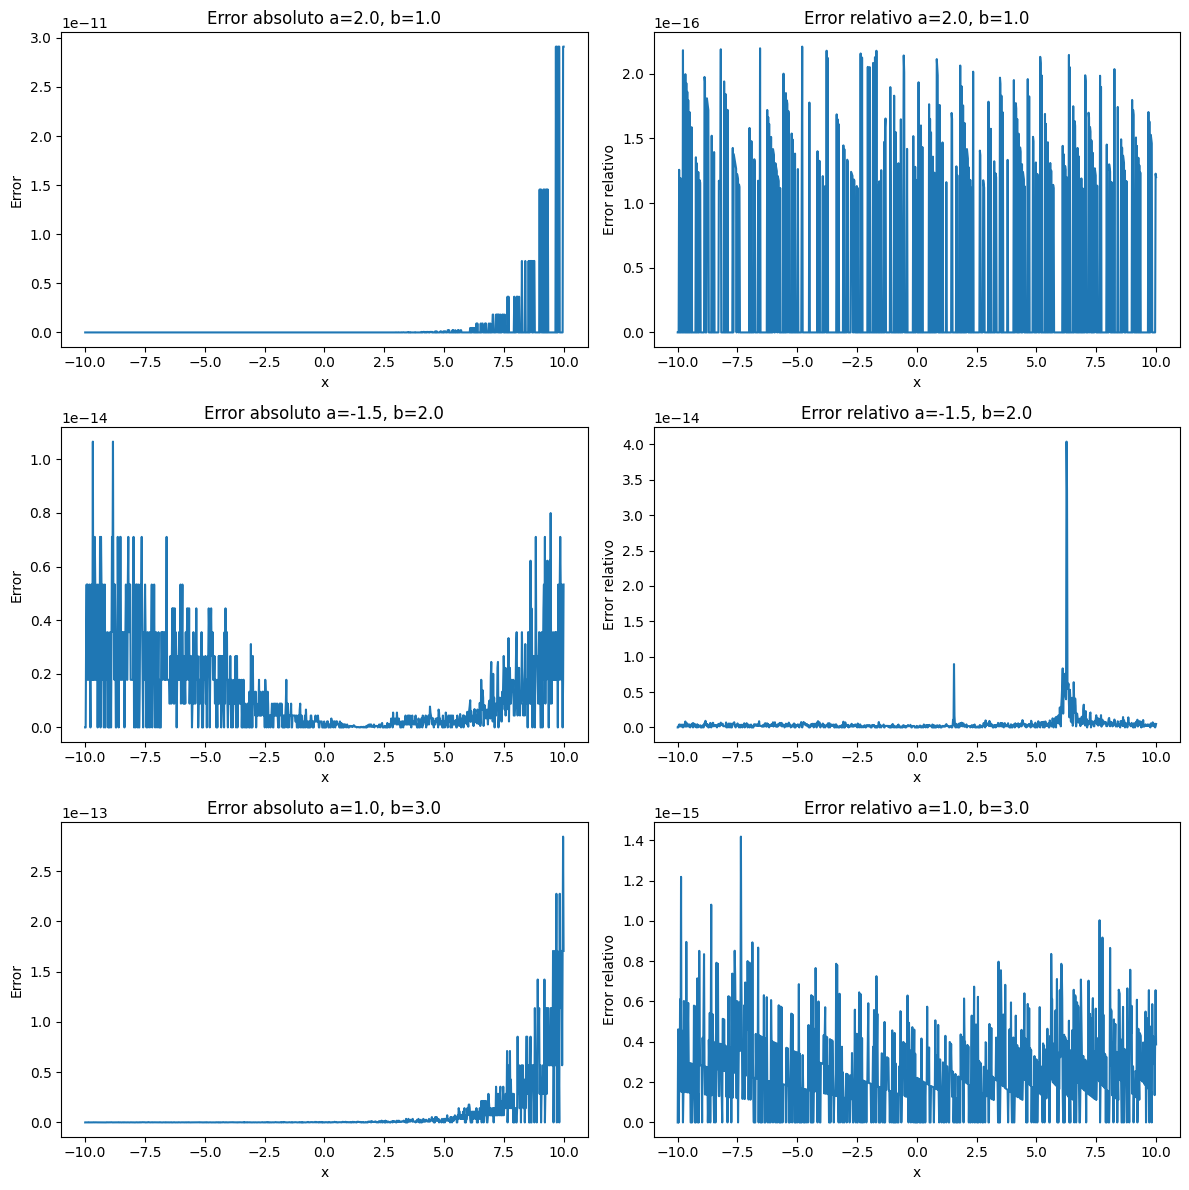

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath
import scipy.special

mpmath.mp.dps = 50  # Precisión alta con mpmath

x_values = np.linspace(-10, 10, 1000)

# Conjuntos de parámetros (a, b) con diferentes características
parametros = [
    (2.0, 1.0),      # a > b, ambos positivos
    (-1.5, 2.0),     # a negativo, b positivo
    (1.0, 3.0),      # a < b, ambos positivos
]

fig, axes = plt.subplots(len(parametros), 2, figsize=(12, 4 * len(parametros)))

for i, (a, b) in enumerate(parametros):
    resultados_mpmath = [mpmath.hyp1f1(a, b, x) for x in x_values]
    resultados_mpmath_float = [float(val.real) for val in resultados_mpmath]
    resultados_scipy = scipy.special.hyp1f1(a, b, x_values)

    error_absoluto = np.abs(np.array(resultados_mpmath_float) - resultados_scipy)
    error_relativo = error_absoluto / (np.abs(resultados_mpmath_float) + 1e-12)

    axes[i, 0].plot(x_values, error_absoluto)
    axes[i, 0].set_title(f'Error absoluto a={a}, b={b}')
    axes[i, 0].set_xlabel('x')
    axes[i, 0].set_ylabel('Error')

    axes[i, 1].plot(x_values, error_relativo)
    axes[i, 1].set_title(f'Error relativo a={a}, b={b}')
    axes[i, 1].set_xlabel('x')
    axes[i, 1].set_ylabel('Error relativo')

plt.tight_layout()
plt.show()


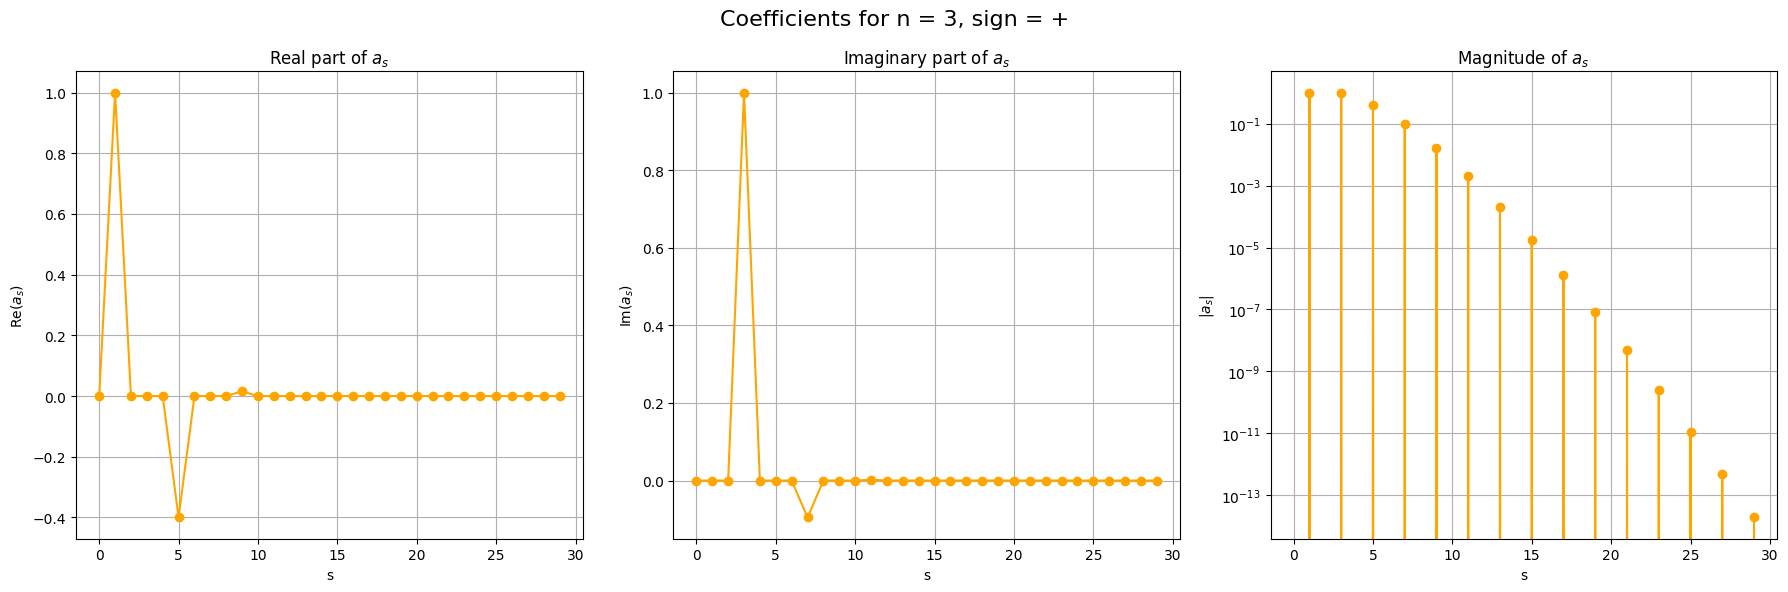

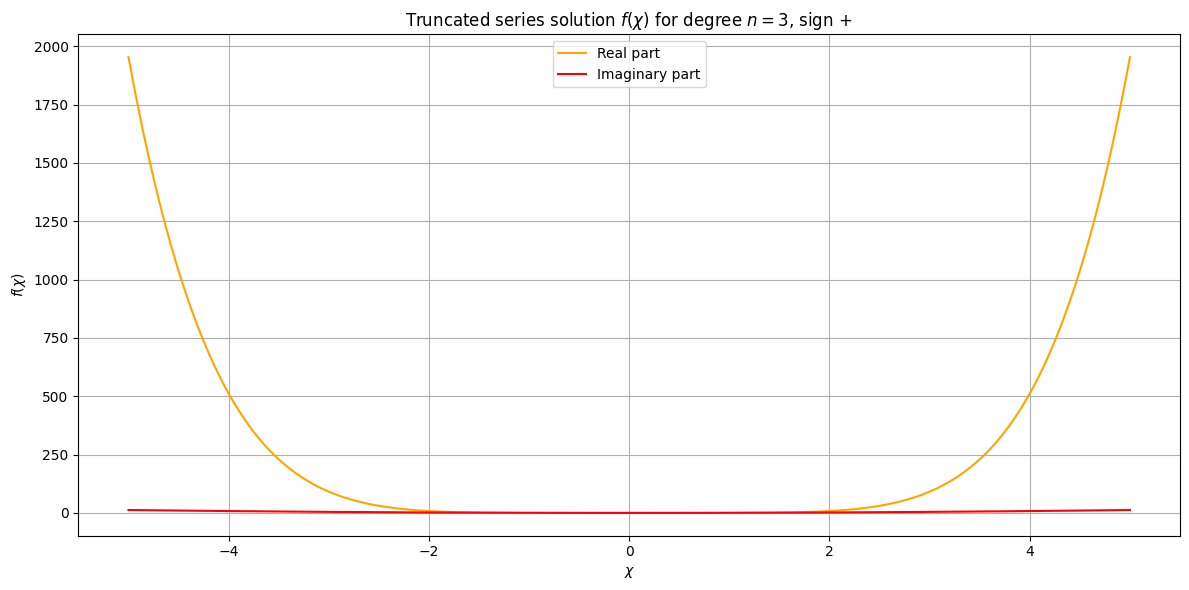

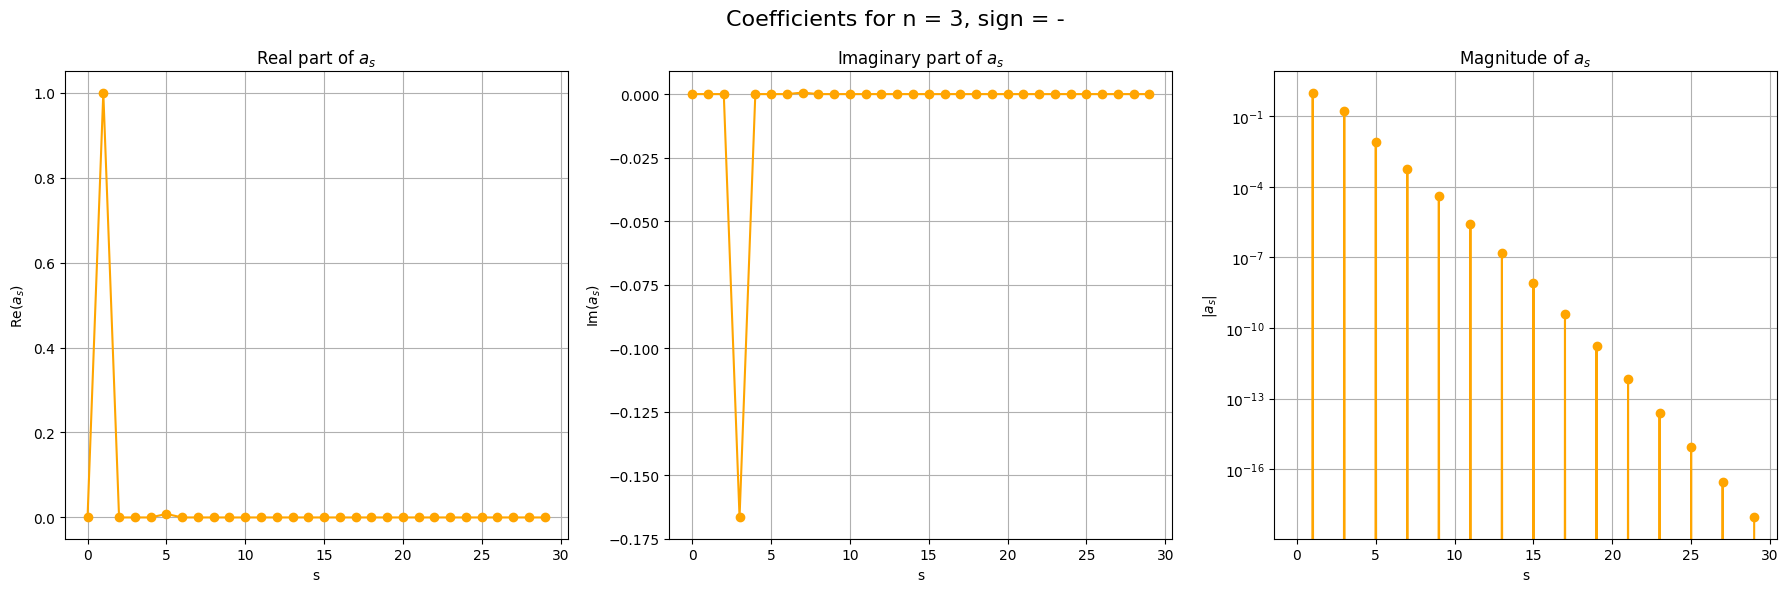

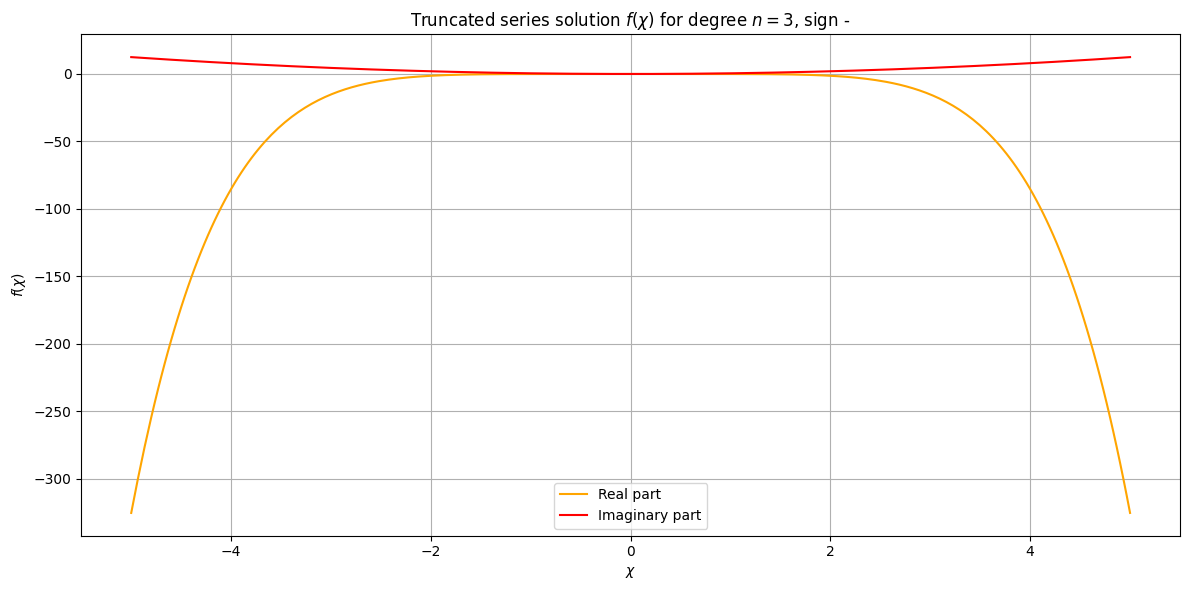

In [32]:
import numpy as np
import matplotlib.pyplot as plt

n = 3

def compute_coefficients(n, sign='+', max_terms=30):
    if sign == '+':
        a_trunc = -1j * (n + 0.5)
    else:
        a_trunc = 1j * (n + 0.5)

    a = np.zeros(max_terms, dtype=complex)
    a[0] = 0
    a[1] = 1

    for s in range(1, max_terms - 1):
        numerator = (-1j * s - 1j / 2 + a_trunc)
        a[s + 1] = -a[s - 1] * numerator / ((s + 1) * s)

    return a

def plot_coefficients(a, n, sign):
    s_vals = np.arange(len(a))

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'Coefficients for n = {n}, sign = {sign}', fontsize=16)

    axes[0].plot(s_vals, np.real(a), 'o-', color='orange')
    axes[0].set_title('Real part of $a_s$')
    axes[0].set_xlabel('s')
    axes[0].set_ylabel('Re($a_s$)')
    axes[0].grid(True)

    axes[1].plot(s_vals, np.imag(a), 'o-', color='orange')
    axes[1].set_title('Imaginary part of $a_s$')
    axes[1].set_xlabel('s')
    axes[1].set_ylabel('Im($a_s$)')
    axes[1].grid(True)

    axes[2].plot(s_vals, np.abs(a), 'o-', color='orange')
    axes[2].set_yscale('log')
    axes[2].set_title('Magnitude of $a_s$')
    axes[2].set_xlabel('s')
    axes[2].set_ylabel('|$a_s$|')
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

def plot_truncated_series(a, n, sign):
    chi = np.linspace(-5, 5, 300)
    f_chi = np.zeros_like(chi, dtype=complex)
    for s in range(n + 1):
        f_chi += a[s] * (1j * chi**2 / 2) ** s

    plt.figure(figsize=(12, 6))
    plt.plot(chi, np.real(f_chi), label='Real part', color='orange')
    plt.plot(chi, np.imag(f_chi), label='Imaginary part', color='red')
    plt.title(f'Truncated series solution $f(\\chi)$ for degree $n={n}$, sign {sign}')
    plt.xlabel('$\\chi$')
    plt.ylabel('$f(\\chi)$')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

for sign in ['+', '-']:
    coeffs = compute_coefficients(n, sign=sign)
    plot_coefficients(coeffs, n, sign)
    plot_truncated_series(coeffs, n, sign)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp

mp.mp.dps = 30  # Set decimal precision

# Parameters
max_terms_rec = 100  # Terms for recurrence series
max_terms_hyp = 100  # Terms for hypergeometric function
m = 1
n = 1
xi = np.linspace(-1, 1, 300)
eta = np.linspace(-1, 1, 300)
XI, ETA = np.meshgrid(xi, eta)

# Recurrence relations
def even_xi(a, N, n):
    aval = 1j * (4 * n + 1) / 2
    return -a[N] * (2j * N + 1j / 2 - aval) / ((N + 1) * (N + 0.5))

def even_eta(a, N, n):
    aval = 1j * (4 * n + 1) / 2
    return -a[N] * (-2j * N - 1j / 2 + aval) / ((N + 1) * (N + 0.5))

def odd_xi(a, N, n):
    aval = 1j * (4 * n + 1) / 2
    return -a[N] * (2j * N + 3j / 2 - aval) / ((N + 1.5) * (N + 1))

def odd_eta(a, N, n):
    aval = 1j * (4 * n + 1) / 2
    return -a[N] * (-2j * N - 3j / 2 + aval) / ((N + 1.5) * (N + 1))

# Coefficient arrays
coeffs = {
    'xi_even': np.zeros(max_terms_rec, dtype=complex),
    'eta_even': np.zeros(max_terms_rec, dtype=complex),
    'xi_odd': np.zeros(max_terms_rec, dtype=complex),
    'eta_odd': np.zeros(max_terms_rec, dtype=complex)
}

for key in coeffs:
    coeffs[key][0] = 1
    coeffs[key][1] = 1

for N in range(1, max_terms_rec - 1):
    coeffs['xi_even'][N + 1] = even_xi(coeffs['xi_even'], N, n)
    coeffs['eta_even'][N + 1] = even_eta(coeffs['eta_even'], N, n)
    coeffs['xi_odd'][N + 1] = odd_xi(coeffs['xi_odd'], N, n)
    coeffs['eta_odd'][N + 1] = odd_eta(coeffs['eta_odd'], N, n)

# Series evaluation
def f_series(X, coefs, terms):
    S = np.zeros_like(X, dtype=complex)
    for s in range(terms):
        S += coefs[s] * X**s
    return S

# Exponential prefactor
exp_factor = np.exp(1j * (XI**2 - ETA**2) / 4)

# Recurrence solutions
psi_even_rec = exp_factor * (f_series(XI, coeffs['xi_even'], max_terms_rec) * f_series(ETA, coeffs['eta_even'], max_terms_rec))
psi_odd_rec = exp_factor * (f_series(XI, coeffs['xi_odd'], max_terms_rec) * f_series(ETA, coeffs['eta_odd'], max_terms_rec))

# Parameters from Eq. (32)
a_even = m + 1 - 1j * n
b_even = m + 1 - 0.5j * n
a_odd = a_even
b_odd = b_even

# Truncated hypergeometric function
def hyp1f1_truncated(a, b, z, terms):
    sum = mp.mpc(0)
    for k in range(terms):
        term = mp.rf(a, k) / mp.rf(b, k) / mp.fac(k) * z**k
        sum += term
    return sum

# Hypergeometric solutions
hyp_xi = np.array([[complex(hyp1f1_truncated(a_even, b_even, -0.5j * x**2, max_terms_hyp)) for x in row] for row in XI], dtype=complex)
hyp_eta = np.array([[complex(hyp1f1_truncated(a_even, b_even, 0.5j * y**2, max_terms_hyp)) for y in row] for row in ETA], dtype=complex)
hyp_xi_o = np.array([[complex(hyp1f1_truncated(a_odd, b_odd, -0.5j * x**2, max_terms_hyp)) for x in row] for row in XI], dtype=complex)
hyp_eta_o = np.array([[complex(hyp1f1_truncated(a_odd, b_odd, 0.5j * y**2, max_terms_hyp)) for y in row] for row in ETA], dtype=complex)

# Full wavefunctions
psi_even_hyp = exp_factor * (hyp_xi * hyp_eta)
psi_odd_hyp = exp_factor * (XI * ETA * hyp_xi_o * hyp_eta_o)

# Plotting
fig = plt.figure(figsize=(18, 10))

ax1 = fig.add_subplot(231, projection='3d')
ax1.plot_surface(XI, ETA, np.real(psi_even_rec), cmap='viridis')
ax1.set_title('Re[ψ_even (rec)]')

ax2 = fig.add_subplot(232, projection='3d')
ax2.plot_surface(XI, ETA, np.real(psi_even_hyp), cmap='viridis')
ax2.set_title('Re[ψ_even (hyp)]')

ax3 = fig.add_subplot(233, projection='3d')
ax3.plot_surface(XI, ETA, np.abs(psi_even_rec - psi_even_hyp), cmap='magma')
ax3.set_title('|Δψ_even|')

ax4 = fig.add_subplot(234, projection='3d')
ax4.plot_surface(XI, ETA, np.real(psi_odd_rec), cmap='plasma')
ax4.set_title('Re[ψ_odd (rec)]')

ax5 = fig.add_subplot(235, projection='3d')
ax5.plot_surface(XI, ETA, np.real(psi_odd_hyp), cmap='plasma')
ax5.set_title('Re[ψ_odd (hyp)]')

ax6 = fig.add_subplot(236, projection='3d')
ax6.plot_surface(XI, ETA, np.abs(psi_odd_rec - psi_odd_hyp), cmap='magma')
ax6.set_title('|Δψ_odd|')

plt.tight_layout()
plt.show()
